# Compare SEP-extracted vs HSC Pre-computed Metrics
Compares our SEP results with the official HSC measurements in the HSC dataset.

In [13]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Use fit_sersic CSV so Sersic Index is the proper 1D profile fit, not the proxy
SEP_CSV   = "./results/testing_images_metrics_wy_fit_sersic.csv"
HDF5_PATH = "/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5"

sep_df = pd.read_csv(SEP_CSV)
print(f"SEP results: {len(sep_df)} images")


SEP results: 33029 images


## Load HSC pre-computed values for same images

In [14]:
indices = sep_df["Image Index"].values.astype(int)

with h5py.File(HDF5_PATH, "r") as f:
    hdf5_ellipticity = f["g_ellipticity"][indices]
    hdf5_major_axis  = f["g_major_axis"][indices]
    hdf5_isophotal   = f["g_isophotal_area"][indices]
    hdf5_sersic      = f["g_sersic_index"][indices]

print("HSC values loaded for", len(indices), "images")

HSC values loaded for 33029 images


## Scatter plot comparison

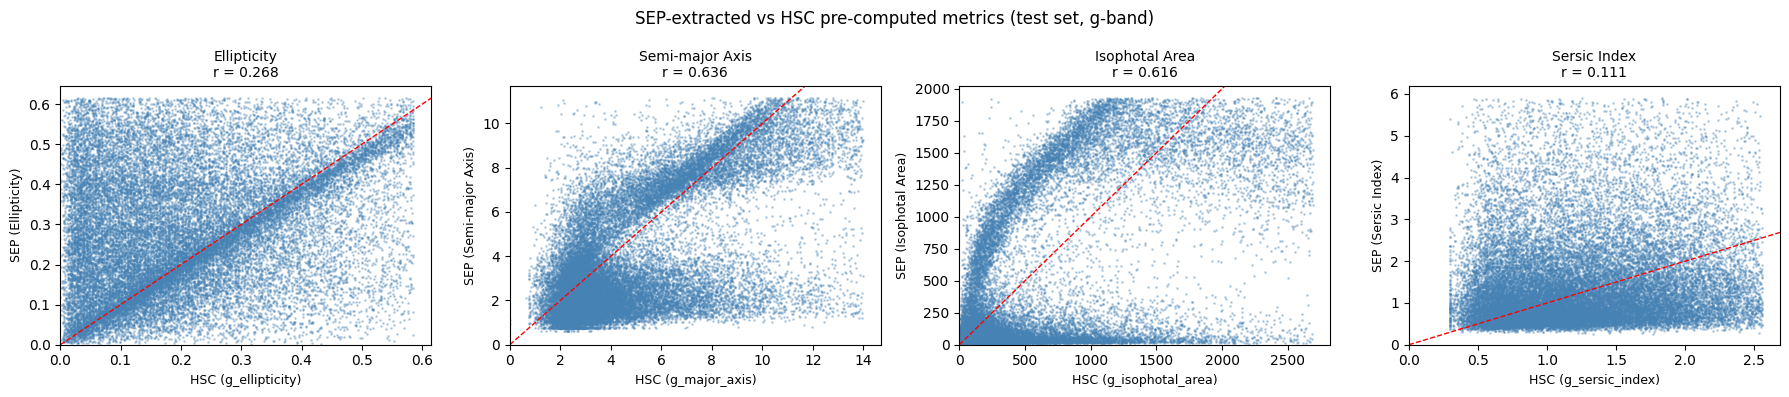

In [15]:
metrics = [
    ("Ellipticity",          sep_df["Ellipticity"].values,            hdf5_ellipticity, "g_ellipticity"),
    ("Semi-major Axis",      sep_df["Semi-major Axis"].values,        hdf5_major_axis,  "g_major_axis"),
    ("Isophotal Area",       sep_df["Isophotal Area"].values,         hdf5_isophotal,   "g_isophotal_area"),
    ("Sérsic Index
(fitted)", sep_df["Sersic Index (fitted)"].values, hdf5_sersic, "g_sersic_index"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, sep_vals, hdf5_vals, hdf5_key) in zip(axes, metrics):
    sep_s    = pd.Series(sep_vals).dropna()
    hdf5_s   = pd.Series(hdf5_vals)[sep_s.index]
    # drop any remaining NaNs in hdf5
    valid    = hdf5_s.notna()
    sep_s, hdf5_s = sep_s[valid], hdf5_s[valid]
    p95_sep  = np.percentile(sep_s, 95)
    p95_hdf5 = np.percentile(hdf5_s, 95)
    mask = (sep_s < p95_sep) & (hdf5_s < p95_hdf5)
    r, _ = pearsonr(sep_s[mask], hdf5_s[mask])
    ax.scatter(hdf5_s[mask], sep_s[mask], s=1, alpha=0.3, color="steelblue")
    lim = max(p95_sep, p95_hdf5)
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_xlabel(f"HSC ({hdf5_key})", fontsize=9)
    ax.set_ylabel(f"SEP ({name})", fontsize=9)
    ax.set_title(f"{name}
r = {r:.3f}", fontsize=10)
    ax.set_xlim(0, p95_hdf5 * 1.05)
    ax.set_ylim(0, p95_sep  * 1.05)

plt.suptitle("SEP-extracted vs HSC pre-computed metrics (test set, g-band)", fontsize=12)
plt.tight_layout()
plt.savefig("./figures/compare_sep_vs_hdf5.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Valid Sersic fits used: {mask.sum():,} / {len(sep_s):,}")


## Mean comparison table

In [16]:
rows = []
for name, sep_vals, hdf5_vals, _ in metrics:
    s = np.nanmean(sep_vals)
    h = np.nanmean(hdf5_vals)
    rows.append({"Metric": name, "SEP mean": round(s,4), "HSC mean": round(h,4), "Ratio SEP/HSC": round(s/h,4)})

table = pd.DataFrame(rows)
display(table)

,Metric,SEP mean,HSC mean,Ratio SEP/HSC
0,Ellipticity,0.3078,0.2345,1.3128
1,Semi-major Axis,4.5919,5.7360,0.8005
2,Isophotal Area,558.4520,727.7046,0.7674
3,Sersic Index,2.0507,1.3433,1.5266


## Compare HFD5 test and repo test

In [17]:
import pandas as pd
import h5py
import numpy as np

df = pd.read_csv('/Users/wen/Desktop/project/lizarraga_2024-main/Metrics/results/testing_metrics.csv')

with h5py.File('/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5', 'r') as f:
    idx = df['Sequential Index'].values.astype(int)
    hdf5_ellipticity = f['g_ellipticity'][idx]
    hdf5_major_axis  = f['g_major_axis'][idx]
    hdf5_sersic      = f['g_sersic_index'][idx]
    hdf5_isophotal   = f['g_isophotal_area'][idx]

# compare across multiple row ranges
for label, rows in [('rows 0-4', range(5)), ('rows 100-104', range(100, 105)), ('rows 500-504', range(500, 505))]:
    print(f"\n=== {label} ===")
    print(f"{'Row':<6} {'CSV Ellip':>12} {'HSC Ellip':>12} {'Match':>8}")
    for i in rows:
        match = '✓' if abs(df['Ellipticity'].iloc[i] - hdf5_ellipticity[i]) < 0.001 else '✗'
        print(f"{i:<6} {df['Ellipticity'].iloc[i]:>12.4f} {hdf5_ellipticity[i]:>12.4f} {match:>8}")

# overall correlation
corr_e = np.corrcoef(df['Ellipticity'].values, hdf5_ellipticity)[0,1]
corr_a = np.corrcoef(df['Semi-major Axis'].values, hdf5_major_axis)[0,1]
print(f"\nOverall correlation coefficients:")
print(f"  Ellipticity:    r = {corr_e:.6f}")
print(f"  Semi-major Axis: r = {corr_a:.6f}")



=== 前5行 ===
Row       CSV Ellip    HSC Ellip    Match
0            0.1470       0.1470        ✓
1            0.1300       0.1300        ✓
2            0.2090       0.2090        ✓
3            0.5250       0.5250        ✓
4            0.7380       0.7380        ✓

=== 第100-105行 ===
Row       CSV Ellip    HSC Ellip    Match
100          0.1460       0.1460        ✓
101          0.1360       0.1360        ✓
102          0.5250       0.5250        ✓
103          0.0730       0.0730        ✓
104          0.3300       0.3300        ✓

=== 第500-505行 ===
Row       CSV Ellip    HSC Ellip    Match
500          0.0610       0.0610        ✓
501          0.3700       0.3700        ✓
502          0.0670       0.0670        ✓
503          0.2930       0.2930        ✓
504          0.2950       0.2950        ✓

整体相关系数:
  Ellipticity:    r = 1.000000
  Semi-major Axis: r = 1.000000
